In [ ]:
#House price perdiction model

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
df = pd.read_csv(r"housing.csv")

#checking null values
print(df.isnull().sum())

In [ ]:
#filling missing values
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median(),
    inplace = True
)

In [ ]:
#deleting unnecessary columns
df.drop(
    columns=["ocean_proximity"],
    inplace=True)

In [ ]:
print(df.head())

In [ ]:
#splitting data
X = df.drop("median_house_value",axis=1)
y = df["median_house_value"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(x_train.head(),"\n test \n\n",y_train.head())

In [ ]:
#scaling the data
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)


In [ ]:
#training model using LinearRegression
model = LinearRegression()
model.fit(x_train_scaled,y_train)
prediction = model.predict(x_test_scaled)
print(prediction)


In [44]:
#evaluating

mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 51810.48362804263
MSE: 5059928371.1653595
R2 Score: 0.6138664756435174


In [46]:
#using RandomForest
RF_model = RandomForestRegressor()
RF_model.fit(x_train_scaled,y_train)
RF_prediction = RF_model.predict(x_test_scaled)

In [47]:
#evaluating with second model

mae = mean_absolute_error(y_test, RF_prediction)
mse = mean_squared_error(y_test, RF_prediction)
r2 = r2_score(y_test, RF_prediction)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 32212.746654554263
MSE: 2469369819.085713
R2 Score: 0.8115573183571584


In [67]:
#using Gradient Boosting
GB_model = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

GB_model.fit(x_train_scaled,y_train)
GB_prediction = GB_model.predict(x_test_scaled)

In [68]:
#evaluating with Third model (Gradient Boosting)

mae = mean_absolute_error(y_test, GB_prediction)
mse = mean_squared_error(y_test, GB_prediction)
r2 = r2_score(y_test, GB_prediction)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 32489.323873566515
MSE: 2356771822.6169925
R2 Score: 0.8201499026829978


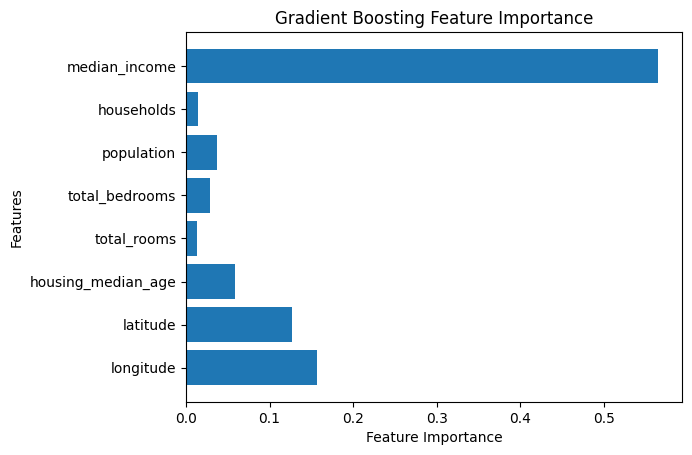

In [70]:
import matplotlib.pyplot as plt

importances = GB_model.feature_importances_
features = x_train.columns  # or your feature names

plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Gradient Boosting Feature Importance")
plt.show()

In [ ]:
#saving the model, as Gradient Boosting evaluate better than others
import joblib

joblib.dump(GB_model, "House_price_prediction_model.pkl")
joblib.dump(scale, "scaler.pkl")

print(" Model and scaler saved successfully.")


 Model and scaler saved successfully.
